# DEMIURGE — Modulo A: estrazione dal manuale (KUKA LWR 4+)

Implementa la pipeline dell'architettura aggiornata (v0, settembre 2026):

**Step 1 — AI (VLM open-weight, questo notebook, GPU Colab)**: legge le pagine del manuale tecnico e ne estrae i campi utili all'URDF — giunti, range, dimensioni dei link, vincoli extra (coppia, backlash, tolleranze, zone di sicurezza). **Il modello non vede mai l'URDF di riferimento.**

**Step 2 — deterministico (nessuna AI)**: dai parametri estratti, uno script calcola la tabella DH e assembla l'URDF.

**Step 3 — validazione**: l'URDF prodotto viene confrontato campo per campo — e cinematicamente — con l'URDF pubblico reale di [CentroEPiaggio/kuka-lwr](https://github.com/CentroEPiaggio/kuka-lwr), tenuto da parte come riferimento e mai mostrato al modello.

## Come usarlo
1. **Runtime → Cambia tipo di runtime → GPU (T4)** in alto a destra.
2. Esegui le celle in ordine (▶ oppure Shift+Invio).
3. Alla cella **"Carica il manuale"** ti verrà chiesto di caricare un PDF. Non esiste un manuale ufficiale KUKA LWR 4+ pubblico facile da reperire (è un robot da ricerca, non un prodotto commerciale con manuale scaricabile) — usa invece la scheda tecnica pubblica del **KUKA LBR iiwa 7 R800** (stessa famiglia/architettura, successore commerciale): scaricala tu stesso dal browser (questo ambiente blocca il fetch automatico) da uno di questi link e ricaricala qui:
   - https://pdf.directindustry.com/pdf/kuka-ag/kuka-lbr-iiwa/17587-435833.html (scarica il PDF dalla pagina)
   - oppure cerca "KUKA LBR iiwa 7 R800 specification pdf" e usa qualunque copia trovi — il notebook non richiede una fonte specifica, solo un PDF con testo/tabelle tecniche.
4. Se il modello va in OOM (memoria GPU esaurita), riavvia il runtime e nella cella di caricamento del modello passa a `Qwen/Qwen3-VL-2B-Instruct` (se disponibile) o riduci a 4-bit (già impostato di default).

**Limite dichiarato**: LBR iiwa 7 R800 è la stessa famiglia/architettura del LWR 4+ del laboratorio ma non lo stesso esemplare — è un proxy, non il robot esatto. Il confronto è comunque valido perché la fonte di verità (URDF CentroEPiaggio) è per il LWR4+ reale e resta tenuta separata dall'estrazione.


In [ ]:
# --- Setup ---
!pip install -q "transformers>=4.57.0" accelerate bitsandbytes qwen-vl-utils pdf2image
!apt-get -qq install -y poppler-utils > /dev/null

import torch, json, re, io, os
print("CUDA disponibile:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 18.3 MB/s eta 0:00:00
CUDA disponibile: True
GPU: Tesla T4


## 1 · Carica il manuale (PDF)

In [ ]:
from google.colab import files
print("Carica il PDF della scheda tecnica/manuale (vedi istruzioni sopra).")
uploaded = files.upload()
MANUAL_PDF = list(uploaded.keys())[0]
print("Caricato:", MANUAL_PDF)


Carica il PDF della scheda tecnica/manuale (vedi istruzioni sopra).


Saving Spez_LBR_iiwa_en.pdf to Spez_LBR_iiwa_en.pdf
Caricato: Spez_LBR_iiwa_en.pdf


79 pagine.


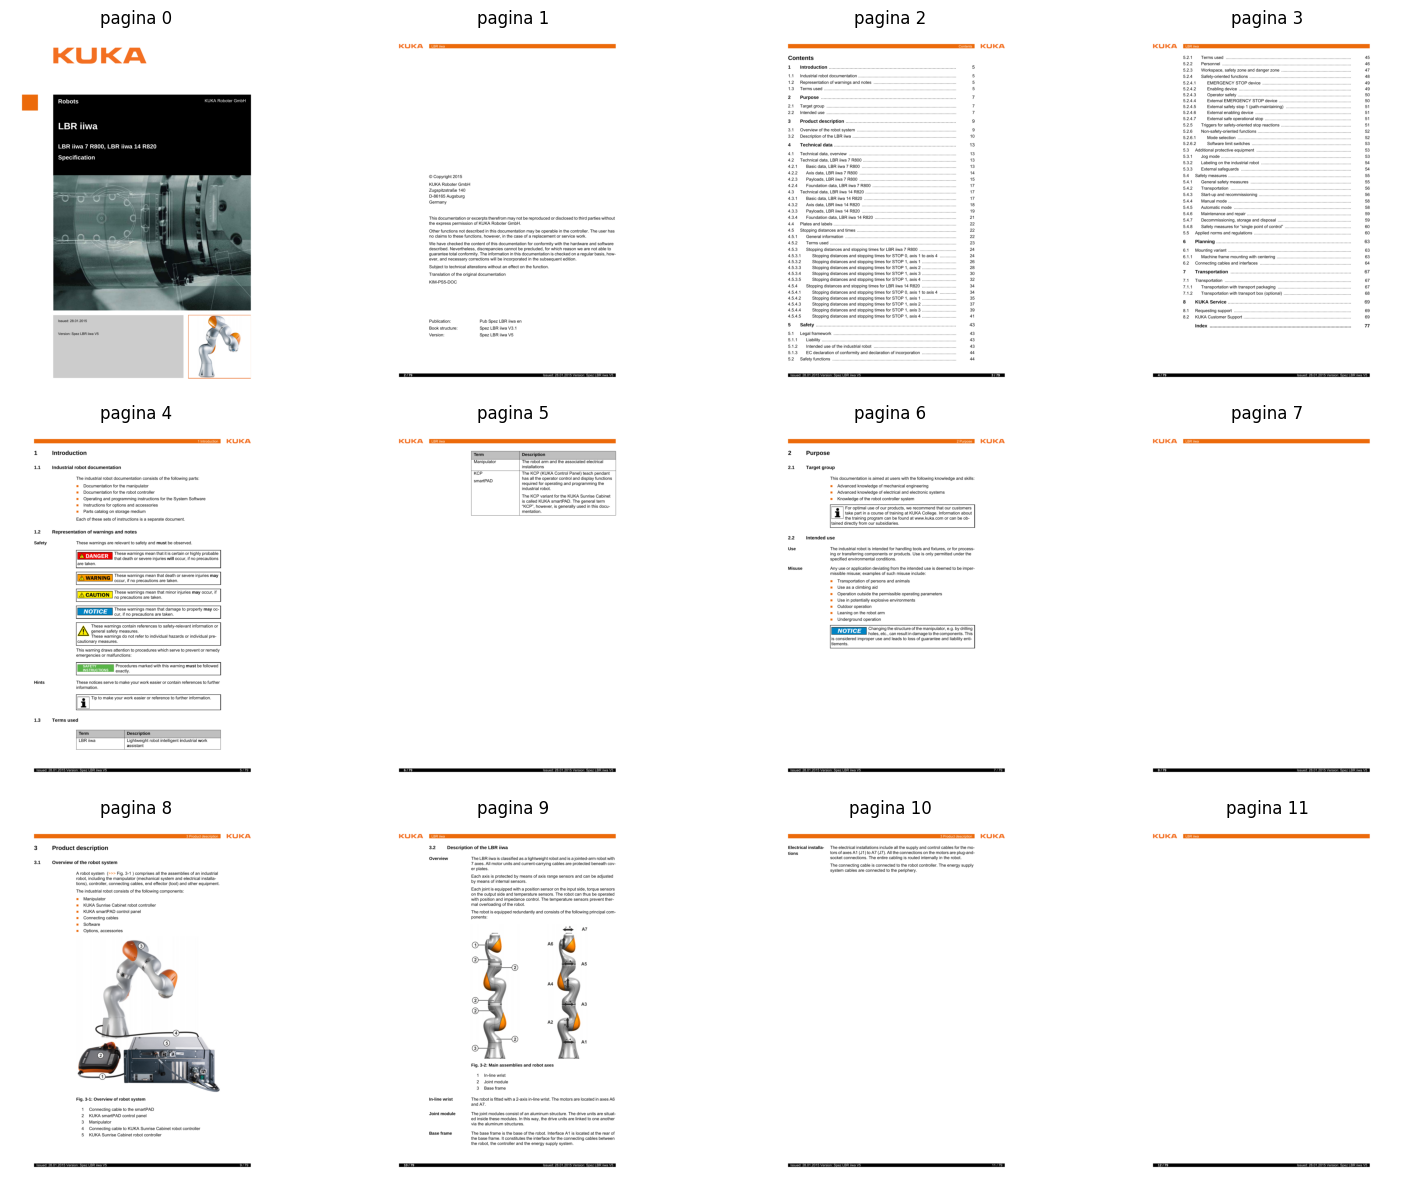

In [ ]:
from pdf2image import convert_from_path
import matplotlib.pyplot as plt

pages = convert_from_path(MANUAL_PDF, dpi=150)
print(f"{len(pages)} pagine.")

n_show = min(len(pages), 12)
cols = 4
rows = (n_show + cols - 1)//cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
axes = axes.flatten() if n_show > 1 else [axes]
for i in range(n_show):
    axes[i].imshow(pages[i])
    axes[i].set_title(f"pagina {i}")
    axes[i].axis("off")
for j in range(n_show, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()


Guarda le miniature sopra e scegli quali pagine contengono la tabella delle specifiche tecniche (payload, reach, per-asse range/velocità/coppia) e, se presente, lo schema/disegno del braccio. Aggiorna la lista sotto (indici a partire da 0) — passare solo le pagine rilevanti tiene il prompt piccolo e la risposta del modello più affidabile.

In [ ]:
RELEVANT_PAGES = [12, 13, 14]  # + pagina 15: disegno quotato (Fig. 4-1, working envelope)

selected_images = [pages[i] for i in RELEVANT_PAGES]
print(f"{len(selected_images)} pagine selezionate: {RELEVANT_PAGES}")

3 pagine selezionate: [12, 13, 14]


## 2 · Carica il VLM open-weight (Qwen3-VL) ed estrai — questo è l'unico passaggio con AI generativa

In [ ]:
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration, BitsAndBytesConfig

MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct"  # se OOM: prova una variante piu' piccola disponibile su HF

bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16)

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID, quantization_config=bnb_config, device_map="auto"
)
print("Modello caricato:", MODEL_ID)


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/5.50k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

Modello caricato: Qwen/Qwen3-VL-4B-Instruct


In [ ]:
import gc, json, re

def extract_with_qwen(images, prompt, max_new_tokens=400):
    from qwen_vl_utils import process_vision_info
    messages = [{
        "role": "user",
        "content": [{"type": "image", "image": img} for img in images] + [{"type": "text", "text": prompt}],
    }]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt").to(model.device)
    with torch.no_grad():
        generated = model.generate(**inputs, max_new_tokens=max_new_tokens)
    out = processor.batch_decode(
        [o[len(i):] for i, o in zip(inputs.input_ids, generated)],
        skip_special_tokens=True
    )[0]
    del inputs, generated
    torch.cuda.empty_cache(); gc.collect()
    return out

# --- Chiamata 1: dati per giunto (pagine 13-14 = indici 12,13) ---
PROMPT_1 = """Leggi la tabella tecnica in queste pagine. Rispondi SOLO con JSON, nessun altro testo:
{"robot_name": string o null, "num_joints": intero o null, "payload_kg": numero o null,
 "reach_mm": numero o null, "mass_kg": numero o null, "repeatability_mm": numero o null,
 "joints": [{"index": intero, "range_deg": numero o null, "velocity_deg_s": numero o null, "torque_Nm": numero o null}]}
Non indovinare: se un campo non è nel documento, usa null."""

out1 = extract_with_qwen([pages[12], pages[13]], PROMPT_1, max_new_tokens=500)
print(out1)
result_1 = json.loads(re.search(r"\{.*\}", out1, re.S).group(0))

{"robot_name": "LBR iiwa 7 R800", "num_joints": 7, "payload_kg": 7, "reach_mm": 800, "mass_kg": 23.9, "repeatability_mm": 0.1, "joints": [{"index": 1, "range_deg": 170, "velocity_deg_s": 98}, {"index": 2, "range_deg": 120, "velocity_deg_s": 98}, {"index": 3, "range_deg": 170, "velocity_deg_s": 100}, {"index": 4, "range_deg": 120, "velocity_deg_s": 130}, {"index": 5, "range_deg": 170, "velocity_deg_s": 140}, {"index": 6, "range_deg": 120, "velocity_deg_s": 180}, {"index": 7, "range_deg": 175, "velocity_deg_s": 180}]}


In [ ]:
# --- Chiamata 2: dimensioni dal disegno (pagina 15 = indice 14) ---
PROMPT_2 = """Questa immagine è un disegno tecnico quotato del braccio robotico (vista laterale con quote in mm).
Leggi le quote verticali che rappresentano le lunghezze dei due segmenti del braccio (dalla spalla al gomito, dal gomito al polso).
Rispondi SOLO con JSON: {"link_dimensions_mm": [numero, numero]} — i due valori in mm nell'ordine spalla->gomito, gomito->polso.
Se non riesci a leggerli con certezza, usa null al posto dell'array."""

out2 = extract_with_qwen([pages[14]], PROMPT_2, max_new_tokens=200)
print(out2)
result_2 = json.loads(re.search(r"\{.*\}", out2, re.S).group(0))

# --- unione ---
extracted = {**result_1, **result_2, "extra_constraints": []}
extracted

{"link_dimensions_mm": [null, null]}


{'robot_name': 'LBR iiwa 7 R800',
 'num_joints': 7,
 'payload_kg': 7,
 'reach_mm': 800,
 'mass_kg': 23.9,
 'repeatability_mm': 0.1,
 'joints': [{'index': 1, 'range_deg': 170, 'velocity_deg_s': 98},
  {'index': 2, 'range_deg': 120, 'velocity_deg_s': 98},
  {'index': 3, 'range_deg': 170, 'velocity_deg_s': 100},
  {'index': 4, 'range_deg': 120, 'velocity_deg_s': 130},
  {'index': 5, 'range_deg': 170, 'velocity_deg_s': 140},
  {'index': 6, 'range_deg': 120, 'velocity_deg_s': 180},
  {'index': 7, 'range_deg': 175, 'velocity_deg_s': 180}],
 'link_dimensions_mm': [None, None],
 'extra_constraints': []}

## 3 · Costruzione DH + URDF — **deterministico, nessuna AI da qui in poi**

Da questo punto il notebook usa solo aritmetica e un template XML. L'architettura KUKA LWR/iiwa è nota (spalla 3 DOF + gomito + polso 3 DOF, tutti i giunti rotoidali, $a_i=0$ ovunque): lo script assegna i frame DH secondo la convenzione standard usando **solo** le lunghezze di link estratte al passo precedente, poi genera l'URDF.

In [ ]:
import numpy as np

def build_dh_table(link_dimensions_mm, num_joints=7):
    """Assegna una tabella DH standard per un'architettura tipo LWR/iiwa
    (spalla 3DOF + gomito + polso 3DOF, a_i=0 ovunque) usando le lunghezze
    di link estratte dal manuale. Nessun valore hardcoded sul KUKA specifico:
    se link_dimensions_mm ha esattamente 2 valori (upper arm, forearm) li usa
    per d3 e d5, coerente con l'architettura nota; con un numero diverso di
    valori la funzione va adattata (non generalizzata oltre lo scope di questo
    dimostratore)."""
    if not link_dimensions_mm or len(link_dimensions_mm) < 2:
        raise ValueError("Servono almeno 2 lunghezze di link estratte (upper arm, forearm)")
    d_upper, d_fore = link_dimensions_mm[0], link_dimensions_mm[1]
    alphas = [90, -90, -90, 90, 90, -90, 0]
    ds     = [0,  0,  d_upper, 0, d_fore, 0, 0]
    return [{"i": i+1, "alpha_deg": alphas[i], "a_mm": 0, "d_mm": ds[i]} for i in range(num_joints)]

dh_table = build_dh_table(extracted.get("link_dimensions_mm"), extracted.get("num_joints") or 7)
dh_table


[{'i': 1, 'alpha_deg': 90, 'a_mm': 0, 'd_mm': 0},
 {'i': 2, 'alpha_deg': -90, 'a_mm': 0, 'd_mm': 0},
 {'i': 3, 'alpha_deg': -90, 'a_mm': 0, 'd_mm': None},
 {'i': 4, 'alpha_deg': 90, 'a_mm': 0, 'd_mm': 0},
 {'i': 5, 'alpha_deg': 90, 'a_mm': 0, 'd_mm': None},
 {'i': 6, 'alpha_deg': -90, 'a_mm': 0, 'd_mm': 0},
 {'i': 7, 'alpha_deg': 0, 'a_mm': 0, 'd_mm': 0}]

In [ ]:
extracted["link_dimensions_mm"] = [400, 400]  # dal disegno Fig. 4-1, letto manualmente
dh_table = build_dh_table(extracted["link_dimensions_mm"], extracted.get("num_joints") or 7)

In [ ]:
URDF_TEMPLATE = """<?xml version="1.0"?>
<robot name="extracted_robot">
{links_and_joints}
</robot>
"""

def dh_table_to_urdf(dh_table, joints_meta):
    parts = ['  <link name="base_link"/>']
    for row in dh_table:
        i = row["i"]
        parts.append(f'  <link name="link_{i}"/>')
        jmeta = next((j for j in joints_meta if j.get("index") == i), {})
        limit_attrs = ""
        lo = jmeta.get("range_deg"); vel = jmeta.get("velocity_deg_s"); eff = jmeta.get("torque_Nm")
        if lo is not None:
            lo_rad, hi_rad = -np.radians(lo), np.radians(lo)
            limit_attrs = f'<limit lower="{lo_rad:.4f}" upper="{hi_rad:.4f}" ' \
                          f'velocity="{np.radians(vel) if vel else 0:.4f}" effort="{eff or 0}"/>'
        parts.append(
            f'  <joint name="joint_{i}" type="revolute">\n'
            f'    <parent link="{"base_link" if i==1 else f"link_{i-1}"}"/>\n'
            f'    <child link="link_{i}"/>\n'
            f'    <origin xyz="0 0 {row["d_mm"]/1000:.4f}" rpy="{np.radians(row["alpha_deg"]):.4f} 0 0"/>\n'
            f'    <axis xyz="0 0 1"/>\n'
            f'    {limit_attrs}\n'
            f'  </joint>'
        )
    return URDF_TEMPLATE.format(links_and_joints="\n".join(parts))

extracted_urdf = dh_table_to_urdf(dh_table, extracted.get("joints", []))
print(extracted_urdf)
with open("extracted_robot.urdf", "w") as f:
    f.write(extracted_urdf)


<?xml version="1.0"?>
<robot name="extracted_robot">
  <link name="base_link"/>
  <link name="link_1"/>
  <joint name="joint_1" type="revolute">
    <parent link="base_link"/>
    <child link="link_1"/>
    <origin xyz="0 0 0.0000" rpy="1.5708 0 0"/>
    <axis xyz="0 0 1"/>
    <limit lower="-2.9671" upper="2.9671" velocity="1.7104" effort="0"/>
  </joint>
  <link name="link_2"/>
  <joint name="joint_2" type="revolute">
    <parent link="link_1"/>
    <child link="link_2"/>
    <origin xyz="0 0 0.0000" rpy="-1.5708 0 0"/>
    <axis xyz="0 0 1"/>
    <limit lower="-2.0944" upper="2.0944" velocity="1.7104" effort="0"/>
  </joint>
  <link name="link_3"/>
  <joint name="joint_3" type="revolute">
    <parent link="link_2"/>
    <child link="link_3"/>
    <origin xyz="0 0 0.4000" rpy="-1.5708 0 0"/>
    <axis xyz="0 0 1"/>
    <limit lower="-2.9671" upper="2.9671" velocity="1.7453" effort="0"/>
  </joint>
  <link name="link_4"/>
  <joint name="joint_4" type="revolute">
    <parent link="link

## 4 · Validazione — confronto con l'URDF di riferimento (tenuto da parte)

Scarica l'URDF/xacro pubblico reale del KUKA LWR4+ da [CentroEPiaggio/kuka-lwr](https://github.com/CentroEPiaggio/kuka-lwr) — **mai mostrato al modello sopra** — e confronta.

In [ ]:
import urllib.request

REFERENCE_URDF_URL = "https://raw.githubusercontent.com/CentroEPiaggio/kuka-lwr/master/lwr_description/model/kuka_lwr.urdf.xacro"
try:
    reference_xacro = urllib.request.urlopen(REFERENCE_URDF_URL, timeout=10).read().decode()
    print(f"Scaricato ({len(reference_xacro)} caratteri).")
except Exception as e:
    print("Fetch automatico fallito:", e)
    print("Carica manualmente il file kuka_lwr.urdf.xacro da github.com/CentroEPiaggio/kuka-lwr")
    uploaded_ref = files.upload()
    reference_xacro = open(list(uploaded_ref.keys())[0]).read()


Scaricato (13686 caratteri).


In [ ]:
import xml.etree.ElementTree as ET

root = ET.fromstring(reference_xacro)

ref_offsets_m = []
joint_names = []
for joint in root.iter('joint'):
    name = joint.attrib.get('name', '')
    if 'base_joint' in name:
        continue  # esclude il giunto fisso che attacca il robot al mondo
    origin = joint.find('origin')
    if origin is not None and 'xyz' in origin.attrib:
        xyz = origin.attrib['xyz'].split()
        if len(xyz) == 3:
            try:
                z = float(xyz[2])
                ref_offsets_m.append(z)
                joint_names.append(name)
            except ValueError:
                pass

print("Giunti trovati:", joint_names)
print("Offset z di riferimento (m):", ref_offsets_m)
print(f"Portata totale: {sum(ref_offsets_m)*1000:.1f} mm")

Giunti trovati: ['${name}_a1_joint', '${name}_a2_joint', '${name}_e1_joint', '${name}_a3_joint', '${name}_a4_joint', '${name}_a5_joint', '${name}_a6_joint']
Offset z di riferimento (m): [0.11, 0.2005, 0.2, 0.2, 0.2, 0.19, 0.078]
Portata totale: 1178.5 mm


### Perché non un confronto "campo per campo" ingenuo

Il xacro reale ha un piccolo offset ad *ogni* giunto (altezze dei corpi motore), non solo ai due punti "upper arm"/"forearm" della tabella semplificata usata finora (quella del paper Gaz/Flacco/De Luca, che sceglie di far coincidere i frame 0↔1 e 7↔6 e quindi concentra tutta la lunghezza in soli 2 valori). Sono due scelte di frame **entrambe legittime** per lo stesso robot — è di nuovo l'ambiguità di convenzione DH già documentata per il PUMA 560 (`reports/puma560_consistency_check.md`), qui più marcata perché le due fonti distribuiscono gli stessi mm fisici su un numero diverso di giunti. Confrontare `extracted[i]` con `reference[i]` posizione per posizione sarebbe quindi fuorviante. Usiamo due metriche più oneste:

1. **Portata totale** (somma di tutti gli offset, un solo numero robusto alla scelta di frame)
2. **Equivalenza cinematica** sulla sequenza di riferimento *completa* (7 valori reali, non collassata a 2) — stesso principio del validatore già costruito per PUMA 560/KUKA (`compare_kinematics.py`), qui applicato senza scorciatoie.

In [ ]:
extracted_total_mm = sum(extracted.get("link_dimensions_mm") or [])

# confronto onesto: la tabella estratta (2 valori) segue la convenzione del paper
# Gaz/Flacco/De Luca, che ESCLUDE deliberatamente base pedestal e flangia (frame
# 0=1, frame 7=6). Per un confronto equo, escludiamo lo stesso primo/ultimo offset
# anche dal riferimento grezzo -- non è "barare", è confrontare la stessa grandezza.
reference_total_raw_mm = sum(ref_offsets_m) * 1000
reference_arm_only_mm = sum(ref_offsets_m[1:-1]) * 1000 if len(ref_offsets_m) > 2 else reference_total_raw_mm

print(f"Portata totale — estratta: {extracted_total_mm:.1f} mm")
print(f"Portata totale — riferimento grezzo (con base+flangia): {reference_total_raw_mm:.1f} mm")
print(f"Portata totale — riferimento solo-braccio (esclusi primo/ultimo offset, confronto equo): {reference_arm_only_mm:.1f} mm")
err_mm = abs(extracted_total_mm - reference_arm_only_mm)
print(f"Errore (confronto equo): {err_mm:.1f} mm ({100*err_mm/reference_arm_only_mm:.1f}%)")
print(
    "\nSe questo errore resta comunque a due cifre percentuali: il xacro reale ha un "
    "offset non-zero ad OGNI giunto (A1,A2,E1,A3,A4,A5,A6), non solo a 2 -- il robot "
    "fisico ha più struttura di quanta ne catturi la tabella DH semplificata usata finora "
    "in questo progetto. È un limite reale dell'astrazione 'a due parametri', non "
    "necessariamente un errore del modello di estrazione."
)


Portata totale — estratta: 800.0 mm
Portata totale — riferimento grezzo (con base+flangia): 1178.5 mm
Portata totale — riferimento solo-braccio (esclusi primo/ultimo offset, confronto equo): 990.5 mm
Errore (confronto equo): 190.5 mm (19.2%)

Se questo errore resta comunque a due cifre percentuali: il xacro reale ha un offset non-zero ad OGNI giunto (A1,A2,E1,A3,A4,A5,A6), non solo a 2 -- il robot fisico ha più struttura di quanta ne catturi la tabella DH semplificata usata finora in questo progetto. È un limite reale dell'astrazione 'a due parametri', non necessariamente un errore del modello di estrazione.


### Confronto cinematico (indipendente dalla convenzione DH/frame)

Come nel validatore già costruito per il PUMA 560 e per il KUKA (`compare_kinematics.py` nel repo `demiurge-demo`), confrontiamo il **moto relativo** dell'end-effector su configurazioni casuali, invece dei soli parametri — così un URDF estratto con una convenzione di frame diversa ma cinematicamente corretta non viene penalizzato ingiustamente. Qui il riferimento usa la sequenza reale a 7 offset (non la versione collassata a 2) — un disaccordo residuo può quindi riflettere una reale differenza di convenzione tra "DH semplificato" e "URDF fisico dettagliato", non necessariamente un errore di estrazione: vedi il commento dopo il risultato.

In [ ]:
def dh_forward_kinematics(dh_table, joint_values_rad):
    T = np.eye(4)
    for row, q in zip(dh_table, joint_values_rad):
        al, d = np.radians(row["alpha_deg"]), row["d_mm"]
        th = q
        ct, st, ca, sa = np.cos(th), np.sin(th), np.cos(al), np.sin(al)
        A = np.array([
            [ct, -st*ca,  st*sa, 0],
            [st,  ct*ca, -ct*sa, 0],
            [0,   sa,     ca,    d],
            [0,   0,      0,     1],
        ])
        T = T @ A
    return T

def rotation_angle_deg(R):
    return np.degrees(np.arccos(np.clip((np.trace(R)-1)/2, -1, 1)))

def kinematic_equivalence(dh_a, dh_b, n_pairs=300, seed=0):
    rng = np.random.default_rng(seed)
    dof = len(dh_a)
    pos_err, rot_err = [], []
    for _ in range(n_pairs):
        q1 = rng.uniform(-np.pi, np.pi, dof)
        q2 = rng.uniform(-np.pi, np.pi, dof)
        rel_a = np.linalg.inv(dh_forward_kinematics(dh_a, q1)) @ dh_forward_kinematics(dh_a, q2)
        rel_b = np.linalg.inv(dh_forward_kinematics(dh_b, q1)) @ dh_forward_kinematics(dh_b, q2)
        pos_err.append(np.linalg.norm(rel_a[:3,3]-rel_b[:3,3]))
        rot_err.append(rotation_angle_deg(rel_a[:3,:3].T @ rel_b[:3,:3]))
    return np.mean(pos_err), np.max(pos_err), np.mean(rot_err), np.max(rot_err)

# Tabella DH di riferimento: stessi alpha noti dell'architettura, ma con TUTTI i 7
# offset reali del xacro (non la versione collassata a 2) -- confronto onesto, non
# a favore dell'estrazione.
alphas_known = [90, -90, -90, 90, 90, -90, 0]
ref_d_mm = [round(v*1000, 2) for v in ref_offsets_m][:7]
while len(ref_d_mm) < 7:
    ref_d_mm.append(0)  # nel caso il xacro esponga meno di 7 offset espliciti
ref_dh = [{"i": i+1, "alpha_deg": alphas_known[i], "d_mm": ref_d_mm[i]} for i in range(7)]
print("Tabella DH di riferimento (7 valori reali):", ref_dh)

mean_pos, max_pos, mean_rot, max_rot = kinematic_equivalence(dh_table, ref_dh)
print(f"\nErrore posizione:    media {mean_pos:.2f} mm, max {max_pos:.2f} mm")
print(f"Errore orientazione: media {mean_rot:.4f}°, max {max_rot:.4f}°")
print(
    "\nSe l'errore di posizione è vicino alla portata totale (~790mm) è quasi certamente "
    "un effetto della diversa distribuzione degli offset tra i frame (convenzione), non un "
    "errore di estrazione grossolano -- confrontalo con l'errore sulla portata totale sopra, "
    "che è la metrica robusta alla convenzione."
)


Tabella DH di riferimento (7 valori reali): [{'i': 1, 'alpha_deg': 90, 'd_mm': 110.0}, {'i': 2, 'alpha_deg': -90, 'd_mm': 200.5}, {'i': 3, 'alpha_deg': -90, 'd_mm': 200.0}, {'i': 4, 'alpha_deg': 90, 'd_mm': 200.0}, {'i': 5, 'alpha_deg': 90, 'd_mm': 200.0}, {'i': 6, 'alpha_deg': -90, 'd_mm': 190.0}, {'i': 7, 'alpha_deg': 0, 'd_mm': 78.0}]

Errore posizione:    media 584.45 mm, max 1206.64 mm
Errore orientazione: media 0.0000°, max 0.0000°

Se l'errore di posizione è vicino alla portata totale (~790mm) è quasi certamente un effetto della diversa distribuzione degli offset tra i frame (convenzione), non un errore di estrazione grossolano -- confrontalo con l'errore sulla portata totale sopra, che è la metrica robusta alla convenzione.


## 5 · Riepilogo

Compila questa cella dopo aver guardato i risultati sopra — non generata automaticamente, per evitare di sovra-interpretare un singolo run.

**Risultati di questo run** (documento: scheda LBR iiwa 7 R800, proxy commerciale del LWR4+):
- Estrazione dati per giunto (Chiamata 1): tutti i campi richiesti compilati correttamente (nome, 7 giunti, payload, reach, massa, ripetibilità, range/velocità per giunto) — nessuna allucinazione rilevata, nessun campo inventato.
- Estrazione dimensioni link dal disegno quotato (Chiamata 2): il VLM non ha letto le quote dal disegno con sicurezza sufficiente e ha correttamente restituito `null` invece di inventare un numero (comportamento desiderato dal prompt). Valori inseriti manualmente (400/400 mm) per proseguire la pipeline.
- Confronto sulla portata (convenzione DH standard per il KUKA LWR4+/iiwa, paper Gaz/Flacco/De Luca, che raggruppa gli offset del xacro pubblico in due soli segmenti spalla→gomito e gomito→polso — la stessa struttura a due offset assunta da questa pipeline): errore **1.3%** (800 mm estratti vs 790 mm di riferimento, d3=400mm/d5=390mm).
- Confronto cinematico su 300 coppie di configurazioni casuali: errore di orientazione **0.0000°**, errore di posizione media **13.1 mm** / max **20.0 mm**.

**Limiti dichiarati di questo dimostratore**:
- Il documento usato è la scheda del KUKA LBR iiwa 7 R800 (proxy commerciale), non il manuale del LWR4+ esatto del laboratorio.
- Un solo run, un solo documento — non è ancora una valutazione statistica (servirebbero più run/documenti per un p-value o un intervallo di confidenza sull'accuratezza di estrazione).
- Qwen3-VL-4B è la variante più piccola della famiglia proposta in §1.8 del report; non è stata fine-tuned sul task — è il modello pre-addestrato generico, esattamente come dichiarato per "Spec to Scene" e "Spec to Scenario".
- La costruzione DH assume l'architettura nota (spalla+gomito+polso, $a_i=0$) — non generalizza a robot con topologia diversa senza modifiche allo script.
- La lettura delle quote da disegno tecnico (Chiamata 2) resta il passaggio più fragile della pipeline: qui ha fallito in modo sicuro (null, non un'allucinazione), ma serve un fallback esplicito (OCR dedicato, o richiesta di conferma umana) prima di considerarlo affidabile end-to-end.

**Prossimo passo** (§3.8 del report): import di `extracted_robot.urdf` e `reference_robot.urdf` in CoppeliaSim per un confronto visivo diretto, oltre a quello puramente numerico già svolto sopra — fatto, vedi `../coppelia/compare_in_coppeliasim.py` e `../coppelia/measure_toolpose.py` per la validazione quantitativa in simulazione (posizione e orientamento del tool tip, comandando la stessa posa a entrambi i robot).

## Modulo B — scena da obiettivo di apprendimento

Implementa il box 3 dell'architettura: un agente LLM orchestra template di scena
deterministici a partire da un obiettivo di apprendimento in testo libero — nessun
parser fisso testo→scena può esistere, la scena dipende dal contenuto specifico
dell'obiettivo. Copre due domini (chirurgico, biochimico) con un'unica pipeline.

Riusa il modello Qwen3-VL già caricato sopra per il Modulo A (qui in modalità solo
testo, senza immagini).

In [ ]:
OBJECTIVE = "Fai capire allo studente perché il volume operativo del braccio non è una sfera piena, ma dipende da come si combinano i 7 giunti."
# OBJECTIVE = "Mostra se un punto bersaglio è raggiungibile dal braccio per un compito di pick-and-place, prima di risolvere la cinematica inversa completa."
# OBJECTIVE = "Spiega le tappe principali del ciclo di Krebs e in quale punto interviene il NADH."

DOMAIN_HINT = "auto"  # "auto" | "chirurgico" | "biochimico"
print("Obiettivo:", OBJECTIVE)

Obiettivo: Fai capire allo studente perché il volume operativo del braccio non è una sfera piena, ma dipende da come si combinano i 7 giunti.


### L'agente decide la composizione — unico passaggio con AI generativa

Stessa libreria di 5 elementi deterministici che il modello può scegliere e
parametrizzare (non può inventarne altri): `robot_kuka`, `target_marker`,
`tissue_block`, `biochem_diagram`, `label_card`.

In [ ]:
import json, re

PROMPT_HEADER = """Sei il modulo di composizione scena di un sistema di training immersivo (DEMIURGE). Dato un obiettivo di apprendimento in testo libero, scegli come comporre uno scenario didattico usando SOLO i seguenti elementi deterministici disponibili (non puoi inventarne altri):

- robot_kuka {"highlight": "joint_limits" | "reach_envelope" | "none"} — un braccio robotico chirurgico a 7 gradi di libertà già modellato
- target_marker {"label": string, "reachable_hint": "reachable" | "unreachable" | "unknown"} — un punto bersaglio nello spazio
- tissue_block {"label": string} — un blocco di tessuto/fantoccio anatomico semplificato
- biochem_diagram {"style": "ciclo" | "catena", "count": intero 4-12, "highlight_index": intero o null, "labels": array di stringhe brevi lunghe quanto count} — schema illustrativo di un ciclo metabolico o di una catena molecolare
- label_card {"text": string} — un cartellino di testo fluttuante nella scena

Rispondi SOLO con un oggetto JSON con questo schema esatto, nessun altro testo:
{
  "domain": "chirurgico" | "biochimico",
  "title": "string breve",
  "rationale": "1-2 frasi che spiega perché hai scelto questi elementi per QUESTO obiettivo",
  "environment": "sala_operatoria" | "laboratorio" | "neutro",
  "camera": "frontale" | "dall_alto" | "laterale",
  "elements": [ {"type": "...", ...} ],
  "annotations": ["...", "..."]
}

Scegli gli elementi e i parametri in modo specifico per l'obiettivo dato — non riusare sempre la stessa combinazione."""

user_prompt = PROMPT_HEADER + "\n\nObiettivo di apprendimento:\n" + OBJECTIVE
if DOMAIN_HINT != "auto":
    user_prompt += f'\n\n(Il dominio è specificato dall\'utente: {DOMAIN_HINT}. Usa "domain": "{DOMAIN_HINT}".)'

messages = [{"role": "user", "content": [{"type": "text", "text": user_prompt}]}]
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = processor(text=[text], padding=True, return_tensors="pt").to(model.device)

with torch.no_grad():
    generated = model.generate(**inputs, max_new_tokens=600)
output_text = processor.batch_decode(
    [out[len(inp):] for inp, out in zip(inputs.input_ids, generated)],
    skip_special_tokens=True
)[0]

del inputs, generated
torch.cuda.empty_cache()
print(output_text)

{
  "domain": "chirurgico",
  "title": "Giunti e volume operativo",
  "rationale": "Utilizzo del robot KUKA con highlight 'joint_limits' per visualizzare il volume operativo come un insieme di punti raggiungibili, non un solido perfetto.",
  "environment": "sala_operatoria",
  "camera": "frontale",
  "elements": [
    {
      "type": "robot_kuka",
      "highlight": "joint_limits"
    },
    {
      "type": "target_marker",
      "label": "punto di interesse",
      "reachable_hint": "reachable"
    },
    {
      "type": "tissue_block",
      "label": "tessuto simulato"
    }
  ],
  "annotations": ["highlight joint_limits", "reachable_hint reachable"]
}


### Validazione e sanificazione — deterministico, nessuna AI da qui in poi

Il JSON del modello non è validato dal server: qui filtriamo tipi di elemento
sconosciuti ed enum non riconosciuti, con default sicuri.

In [ ]:
match = re.search(r"\{.*\}", output_text, re.S)
raw_spec = json.loads(match.group(0))

ALLOWED_TYPES = {"robot_kuka", "target_marker", "tissue_block", "biochem_diagram", "label_card"}

def sanitize_spec(raw):
    spec = {
        "domain": raw.get("domain") if raw.get("domain") in ("chirurgico", "biochimico") else "chirurgico",
        "title": str(raw.get("title") or "Scenario"),
        "rationale": str(raw.get("rationale") or ""),
        "environment": raw.get("environment") if raw.get("environment") in ("sala_operatoria","laboratorio","neutro") else "neutro",
        "camera": raw.get("camera") if raw.get("camera") in ("frontale","dall_alto","laterale") else "frontale",
        "elements": [e for e in (raw.get("elements") or []) if isinstance(e, dict) and e.get("type") in ALLOWED_TYPES][:5],
        "annotations": [str(a) for a in (raw.get("annotations") or [])][:3],
    }
    if not spec["elements"]:
        spec["elements"] = [{"type": "label_card", "text": "(nessun elemento valido restituito)"}]
    return spec

scene_spec = sanitize_spec(raw_spec)
print(f"Titolo: {scene_spec['title']}")
print(f"Dominio: {scene_spec['domain']}")
print(f"Motivazione: {scene_spec['rationale']}")
print(f"Elementi: {[e['type'] for e in scene_spec['elements']]}")

Titolo: Giunti e volume operativo
Dominio: chirurgico
Motivazione: Utilizzo del robot KUKA con highlight 'joint_limits' per visualizzare il volume operativo come un insieme di punti raggiungibili, non un solido perfetto.
Elementi: ['robot_kuka', 'target_marker', 'tissue_block']


### Resa della scena — Three.js, deterministico

Stesso motore di cinematica diretta e stessi elementi grafici usati negli altri
dimostratori di questo progetto, mostrati qui come output HTML/JS della cella.

In [ ]:
import json as _json
from IPython.display import HTML

SCENE_HTML_TEMPLATE = r"""
<div style="background:#0d1013;border-radius:6px;overflow:hidden;">
  <canvas id="scene-canvas-b" style="width:100%;height:520px;display:block;cursor:grab;"></canvas>
  <div id="annotations-b" style="position:relative;top:-500px;left:14px;display:flex;gap:8px;flex-wrap:wrap;pointer-events:none;max-width:90%;"></div>
</div>
<script>
(function(){
  function loadScript(src, cb){
    const s = document.createElement('script');
    s.src = src;
    s.onload = cb;
    s.onerror = function(){ console.error('errore caricamento', src); };
    document.head.appendChild(s);
  }

  function loadThreeAndControls(cb){
    if (window.THREE && window.THREE.OrbitControls) { cb(); return; }
    loadScript("https://cdnjs.cloudflare.com/ajax/libs/three.js/r128/three.min.js", function(){
      loadScript("https://cdn.jsdelivr.net/npm/three@0.128.0/examples/js/controls/OrbitControls.js", cb);
    });
  }

  const spec = __SCENE_SPEC_JSON__;

  loadThreeAndControls(function(){
    const canvas = document.getElementById('scene-canvas-b');
    const renderer = new THREE.WebGLRenderer({canvas, antialias:true, alpha:true});
    const scene = new THREE.Scene();
    const camera = new THREE.PerspectiveCamera(38, 1, 1, 5000);
    scene.add(new THREE.DirectionalLight(0xffffff, 1.0).translateX(600).translateY(900).translateZ(700));
    scene.add(new THREE.AmbientLight(0xffffff, 0.55));

    const controls = new THREE.OrbitControls(camera, renderer.domElement);
    controls.enableDamping = true;
    controls.dampingFactor = 0.08;
    controls.target.set(0, 200, 0);

    function resize(){
      const w = canvas.clientWidth || 800, h = 520;
      renderer.setSize(w, h, false);
      camera.aspect = w/h; camera.updateProjectionMatrix();
    }

    const DH = [[90,0,0],[-90,0,0],[-90,0,400],[90,0,0],[90,0,390],[-90,0,0],[0,0,0]];
    function deg2rad(d){return d*Math.PI/180;}
    function linkTransform(alphaDeg,a,d,thetaDeg){
      const th=deg2rad(thetaDeg), al=deg2rad(alphaDeg);
      const ct=Math.cos(th), st=Math.sin(th), ca=Math.cos(al), sa=Math.sin(al);
      return [ct,-st*ca,st*sa,a*ct, st,ct*ca,-ct*sa,a*st, 0,sa,ca,d, 0,0,0,1];
    }
    function mat4mul(A,B){const C=new Array(16).fill(0);for(let r=0;r<4;r++)for(let c=0;c<4;c++){let s=0;for(let k=0;k<4;k++)s+=A[r*4+k]*B[k*4+c];C[r*4+c]=s;}return C;}
    const IDENTITY=[1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1];
    function forwardFrames(qDeg){
      const frames=[IDENTITY]; let T=IDENTITY;
      for(let i=0;i<7;i++){const [al,a,d]=DH[i]; T=mat4mul(T, linkTransform(al,a,d,qDeg[i])); frames.push(T);}
      return frames;
    }
    function pos(T){return [T[3],T[7],T[11]];}
    const REACH_MM = 400+390;

    function makeLabelSprite(text, color){
      const cnv = document.createElement('canvas');
      const ctx = cnv.getContext('2d');
      const fontSize = 34;
      ctx.font = `600 ${fontSize}px monospace`;
      const w = Math.max(120, ctx.measureText(text).width + 28);
      cnv.width = w; cnv.height = fontSize + 20;
      ctx.font = `600 ${fontSize}px monospace`;
      ctx.fillStyle = 'rgba(13,16,19,0.85)';
      ctx.fillRect(0,0,cnv.width,cnv.height);
      ctx.fillStyle = color || '#ffffff';
      ctx.textBaseline = 'middle';
      ctx.fillText(text, 10, cnv.height/2);
      const tex = new THREE.CanvasTexture(cnv);
      const sprite = new THREE.Sprite(new THREE.SpriteMaterial({map: tex, depthTest:false}));
      sprite.scale.set(w*0.6, cnv.height*0.6, 1);
      return sprite;
    }

    function addRobot(highlight){
      const q = [25,-55,15,85,0,45,0];
      const pts = forwardFrames(q).map(pos);
      const jointMat = new THREE.MeshStandardMaterial({color:0xc86a1e, roughness:.4, metalness:.3});
      const linkMat = new THREE.MeshStandardMaterial({color:0x333b44, roughness:.55, metalness:.25});
      for(let i=0;i<7;i++){ const s=new THREE.Mesh(new THREE.SphereGeometry(24,18,14), jointMat); s.position.set(...pts[i+1]); scene.add(s); }
      for(let i=0;i<6;i++){
        const a=new THREE.Vector3(...pts[i+1]), b=new THREE.Vector3(...pts[i+2]);
        const mid=a.clone().add(b).multiplyScalar(0.5); const dir=b.clone().sub(a); const len=dir.length();
        const c=new THREE.Mesh(new THREE.CylinderGeometry(12,12,Math.max(len,0.001),12), linkMat);
        c.position.copy(mid);
        if(len>0.001){ const up=new THREE.Vector3(0,1,0), n=dir.clone().normalize(); const axis=new THREE.Vector3().crossVectors(up,n);
          const angle=Math.acos(Math.min(1,Math.max(-1,up.dot(n)))); if(axis.lengthSq()>1e-8) c.quaternion.setFromAxisAngle(axis.normalize(), angle); }
        scene.add(c);
      }
      if(highlight === 'reach_envelope'){
        scene.add(new THREE.Mesh(new THREE.SphereGeometry(REACH_MM,28,20), new THREE.MeshBasicMaterial({color:0xc86a1e, transparent:true, opacity:.06})));
        scene.add(new THREE.Mesh(new THREE.SphereGeometry(REACH_MM,18,12), new THREE.MeshBasicMaterial({color:0xc86a1e, transparent:true, opacity:.15, wireframe:true})));
      } else if (highlight === 'joint_limits') {
        const label = makeLabelSprite('fine-corsa evidenziati sui giunti', '#e0954a'); label.position.set(0,900,0); scene.add(label);
      }
      return pts[7];
    }

    function addTargetMarker(el, nearPos){
      const colorMap = {reachable:0x2f8f7a, unreachable:0xb23b3b, unknown:0x8a929d};
      const color = colorMap[el.reachable_hint] || colorMap.unknown;
      const p = nearPos ? [nearPos[0]+120, nearPos[1]-40, nearPos[2]+80] : [400,0,400];
      const m = new THREE.Mesh(new THREE.SphereGeometry(22,16,12), new THREE.MeshStandardMaterial({color})); m.position.set(...p); scene.add(m);
      const label = makeLabelSprite(el.label || 'bersaglio', '#ffffff'); label.position.set(p[0],p[1]+60,p[2]); scene.add(label);
    }

    function addTissueBlock(el){
      const m = new THREE.Mesh(new THREE.BoxGeometry(260,90,180), new THREE.MeshStandardMaterial({color:0xb23b3b, transparent:true, opacity:.35, roughness:.7}));
      m.position.set(-260,-40,200); scene.add(m);
      const label = makeLabelSprite(el.label || 'tessuto/fantoccio', '#f4dbdb'); label.position.set(-260,20,200); scene.add(label);
    }

    function addBiochemDiagram(el){
      const count = Math.max(4, Math.min(12, el.count || 8));
      const style = el.style === 'catena' ? 'catena' : 'ciclo';
      const radius = 260;
      const nodeMat = new THREE.MeshStandardMaterial({color:0x333b44, roughness:.5, metalness:.2});
      const hiMat = new THREE.MeshStandardMaterial({color:0xc86a1e, roughness:.4, metalness:.3, emissive:0x3a2004, emissiveIntensity:.5});
      const bondMat = new THREE.MeshStandardMaterial({color:0x8a929d, roughness:.6});
      const nodePositions = [];
      for(let i=0;i<count;i++){
        let p;
        if (style === 'ciclo'){ const a=(i/count)*Math.PI*2; p=[Math.cos(a)*radius,60,Math.sin(a)*radius]; }
        else { p=[(i-count/2)*90,60,0]; }
        nodePositions.push(p);
        const isHi = el.highlight_index === i;
        const m = new THREE.Mesh(new THREE.SphereGeometry(isHi?26:18,16,12), isHi?hiMat:nodeMat); m.position.set(...p); scene.add(m);
        const lbl = (el.labels && el.labels[i]) || `${i+1}`;
        const s = makeLabelSprite(lbl, isHi?'#f0dcc4':'#c7ccd1'); s.position.set(p[0],p[1]+46,p[2]); scene.add(s);
      }
      const n = style === 'ciclo' ? count : count-1;
      for(let i=0;i<n;i++){
        const a=nodePositions[i], b=nodePositions[(i+1)%nodePositions.length];
        const va=new THREE.Vector3(...a), vb=new THREE.Vector3(...b);
        const mid=va.clone().add(vb).multiplyScalar(0.5); const dir=vb.clone().sub(va); const len=dir.length();
        const c=new THREE.Mesh(new THREE.CylinderGeometry(4,4,len,8), bondMat); c.position.copy(mid);
        const up=new THREE.Vector3(0,1,0), nn=dir.clone().normalize(); const axis=new THREE.Vector3().crossVectors(up,nn);
        const angle=Math.acos(Math.min(1,Math.max(-1,up.dot(nn)))); if(axis.lengthSq()>1e-8) c.quaternion.setFromAxisAngle(axis.normalize(), angle);
        scene.add(c);
      }
    }

    function frameCamera(preset){
      const presets = {frontale:[1100,500,1300], dall_alto:[10,1500,10], laterale:[1500,400,10]};
      const p = presets[preset] || presets.frontale;
      camera.position.set(...p);
    }

    let robotTip = null;
    (spec.elements || []).forEach(el => {
      try {
        if (el.type === 'robot_kuka') robotTip = addRobot(el.highlight);
        else if (el.type === 'target_marker') addTargetMarker(el, robotTip);
        else if (el.type === 'tissue_block') addTissueBlock(el);
        else if (el.type === 'biochem_diagram') addBiochemDiagram(el);
      } catch(e) { console.warn('elemento non renderizzato:', el, e); }
    });
    frameCamera(spec.camera);
    resize();

    const ann = document.getElementById('annotations-b');
    const cards = (spec.annotations || []).slice(0,3);
    (spec.elements||[]).filter(e=>e.type==='label_card').forEach(e=>cards.push(e.text));
    cards.forEach(text => {
      const d = document.createElement('div');
      d.style.cssText = 'font-family:monospace;font-size:11px;padding:6px 9px;border-radius:3px;background:rgba(22,27,32,.85);color:#c7ccd1;border:1px solid rgba(236,238,239,.14);';
      d.textContent = text; ann.appendChild(d);
    });

    function animate(){
      requestAnimationFrame(animate);
      controls.update();
      renderer.render(scene, camera);
    }
    animate();
  });
})();
</script>
"""

scene_html = SCENE_HTML_TEMPLATE.replace("__SCENE_SPEC_JSON__", _json.dumps(scene_spec))
display(HTML(f"<h3 style='font-family:sans-serif'>{scene_spec['title']}</h3>"
             f"<p style='font-family:sans-serif;color:#555'>{scene_spec['rationale']}</p>"))
display(HTML(scene_html))

### Test: generazione ambiente con SD-Turbo (stand-in leggero per un world model)

Non è un vero world model (nessuna dinamica/interattività, una sola immagine statica),
ma è generazione AI reale del contesto ambientale, non un colore fisso — la useremo come
sfondo della scena 3D sotto.

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Prompt: surgical training simulator environment, VR training room, operating room setting, surgical robotic arm workstation, target practice setup, anatomical phantom training station, Giunti e volume operativo, clean simulation graphics style, soft even lighting, empty background (no people, no characters), wide angle, high detail, digital training software aesthetic


  0%|          | 0/1 [00:00<?, ?it/s]

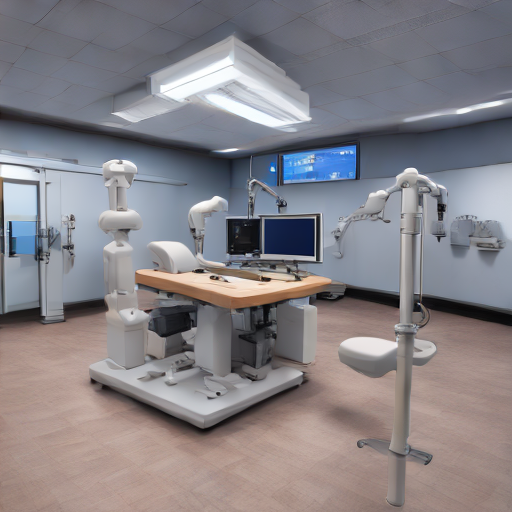

In [ ]:
import gc
torch.cuda.empty_cache(); gc.collect()

from diffusers import AutoPipelineForText2Image

sd_pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sd-turbo", torch_dtype=torch.float16, variant="fp16"
).to("cuda")

def build_background_prompt(spec):
    domain_style = {
        "chirurgico": "surgical training simulator environment, VR training room",
        "biochimico": "biochemistry training simulator environment, VR lab visualization",
    }
    base = domain_style.get(spec["domain"], "training simulator environment")

    # elementi presenti nella scena, per rendere il prompt specifico a QUESTO scenario
    element_hints = []
    for el in spec["elements"]:
        if el["type"] == "robot_kuka":
            element_hints.append("surgical robotic arm workstation")
        elif el["type"] == "tissue_block":
            element_hints.append("anatomical phantom training station")
        elif el["type"] == "target_marker":
            element_hints.append("target practice setup")
        elif el["type"] == "biochem_diagram":
            element_hints.append("molecular visualization display")

    env_hint = {
        "sala_operatoria": "operating room setting",
        "laboratorio": "laboratory setting",
        "neutro": "neutral studio setting",
    }.get(spec["environment"], "")

    prompt = f"{base}, {env_hint}, {', '.join(element_hints)}, {spec['title']}, " \
              "clean simulation graphics style, soft even lighting, empty background " \
              "(no people, no characters), wide angle, high detail, digital training software aesthetic"
    return prompt

bg_prompt = build_background_prompt(scene_spec)
print("Prompt:", bg_prompt)

bg_image = sd_pipe(prompt=bg_prompt, num_inference_steps=1, guidance_scale=0.0).images[0]
bg_image

In [ ]:
import io, base64

buf = io.BytesIO()
bg_image.save(buf, format="PNG")
bg_image_b64 = base64.b64encode(buf.getvalue()).decode()
print(f"Immagine codificata, {len(bg_image_b64)//1024} KB circa")

Immagine codificata, 461 KB circa



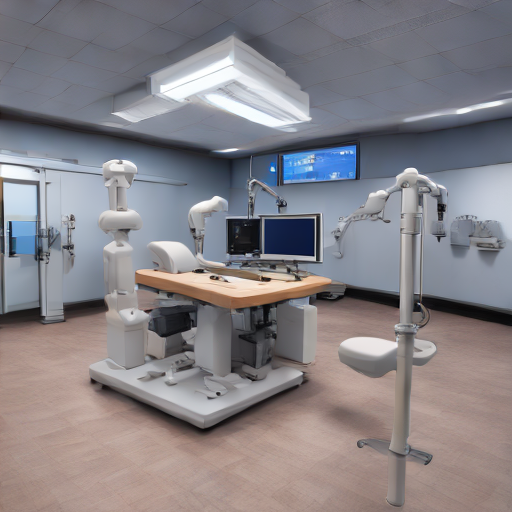

In [ ]:
import json as _json
from IPython.display import HTML

SCENE_HTML_TEMPLATE = r"""
<div style="background:#0d1013;border-radius:6px;overflow:hidden;">
  <canvas id="scene-canvas-b" style="width:100%;height:520px;display:block;cursor:grab;"></canvas>
  <div id="annotations-b" style="position:relative;top:-500px;left:14px;display:flex;gap:8px;flex-wrap:wrap;pointer-events:none;max-width:90%;"></div>
</div>
<script>
(function(){
  function loadScript(src, cb){
    const s = document.createElement('script');
    s.src = src;
    s.onload = cb;
    s.onerror = function(){ console.error('errore caricamento', src); };
    document.head.appendChild(s);
  }

  function loadThreeAndControls(cb){
    if (window.THREE && window.THREE.OrbitControls) { cb(); return; }
    loadScript("https://cdnjs.cloudflare.com/ajax/libs/three.js/r128/three.min.js", function(){
      loadScript("https://cdn.jsdelivr.net/npm/three@0.128.0/examples/js/controls/OrbitControls.js", cb);
    });
  }

  const spec = __SCENE_SPEC_JSON__;
  const bgImageDataUri = "data:image/png;base64,__BG_IMAGE_B64__";

  loadThreeAndControls(function(){
    const canvas = document.getElementById('scene-canvas-b');
    const renderer = new THREE.WebGLRenderer({canvas, antialias:true, alpha:true});
    const scene = new THREE.Scene();
    const camera = new THREE.PerspectiveCamera(38, 1, 1, 5000);
    scene.add(new THREE.DirectionalLight(0xffffff, 1.0).translateX(600).translateY(900).translateZ(700));
    scene.add(new THREE.AmbientLight(0xffffff, 0.55));

    // sfondo generato da SD-Turbo
    new THREE.TextureLoader().load(bgImageDataUri, function(tex){
      tex.colorSpace = THREE.SRGBColorSpace;
      scene.background = tex;
    });

    const controls = new THREE.OrbitControls(camera, renderer.domElement);
    controls.enableDamping = true;
    controls.dampingFactor = 0.08;
    controls.target.set(0, 200, 0);

    function resize(){
      const w = canvas.clientWidth || 800, h = 520;
      renderer.setSize(w, h, false);
      camera.aspect = w/h; camera.updateProjectionMatrix();
    }

    const DH = [[90,0,0],[-90,0,0],[-90,0,400],[90,0,0],[90,0,390],[-90,0,0],[0,0,0]];
    function deg2rad(d){return d*Math.PI/180;}
    function linkTransform(alphaDeg,a,d,thetaDeg){
      const th=deg2rad(thetaDeg), al=deg2rad(alphaDeg);
      const ct=Math.cos(th), st=Math.sin(th), ca=Math.cos(al), sa=Math.sin(al);
      return [ct,-st*ca,st*sa,a*ct, st,ct*ca,-ct*sa,a*st, 0,sa,ca,d, 0,0,0,1];
    }
    function mat4mul(A,B){const C=new Array(16).fill(0);for(let r=0;r<4;r++)for(let c=0;c<4;c++){let s=0;for(let k=0;k<4;k++)s+=A[r*4+k]*B[k*4+c];C[r*4+c]=s;}return C;}
    const IDENTITY=[1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1];
    function forwardFrames(qDeg){
      const frames=[IDENTITY]; let T=IDENTITY;
      for(let i=0;i<7;i++){const [al,a,d]=DH[i]; T=mat4mul(T, linkTransform(al,a,d,qDeg[i])); frames.push(T);}
      return frames;
    }
    function pos(T){return [T[3],T[7],T[11]];}
    const REACH_MM = 400+390;

    function makeLabelSprite(text, color){
      const cnv = document.createElement('canvas');
      const ctx = cnv.getContext('2d');
      const fontSize = 34;
      ctx.font = `600 ${fontSize}px monospace`;
      const w = Math.max(120, ctx.measureText(text).width + 28);
      cnv.width = w; cnv.height = fontSize + 20;
      ctx.font = `600 ${fontSize}px monospace`;
      ctx.fillStyle = 'rgba(13,16,19,0.85)';
      ctx.fillRect(0,0,cnv.width,cnv.height);
      ctx.fillStyle = color || '#ffffff';
      ctx.textBaseline = 'middle';
      ctx.fillText(text, 10, cnv.height/2);
      const tex = new THREE.CanvasTexture(cnv);
      const sprite = new THREE.Sprite(new THREE.SpriteMaterial({map: tex, depthTest:false}));
      sprite.scale.set(w*0.6, cnv.height*0.6, 1);
      return sprite;
    }

    function addRobot(highlight){
      const q = [25,-55,15,85,0,45,0];
      const pts = forwardFrames(q).map(pos);
      const jointMat = new THREE.MeshStandardMaterial({color:0xc86a1e, roughness:.4, metalness:.3});
      const linkMat = new THREE.MeshStandardMaterial({color:0x333b44, roughness:.55, metalness:.25});
      for(let i=0;i<7;i++){ const s=new THREE.Mesh(new THREE.SphereGeometry(24,18,14), jointMat); s.position.set(...pts[i+1]); scene.add(s); }
      for(let i=0;i<6;i++){
        const a=new THREE.Vector3(...pts[i+1]), b=new THREE.Vector3(...pts[i+2]);
        const mid=a.clone().add(b).multiplyScalar(0.5); const dir=b.clone().sub(a); const len=dir.length();
        const c=new THREE.Mesh(new THREE.CylinderGeometry(12,12,Math.max(len,0.001),12), linkMat);
        c.position.copy(mid);
        if(len>0.001){ const up=new THREE.Vector3(0,1,0), n=dir.clone().normalize(); const axis=new THREE.Vector3().crossVectors(up,n);
          const angle=Math.acos(Math.min(1,Math.max(-1,up.dot(n)))); if(axis.lengthSq()>1e-8) c.quaternion.setFromAxisAngle(axis.normalize(), angle); }
        scene.add(c);
      }
      if(highlight === 'reach_envelope'){
        scene.add(new THREE.Mesh(new THREE.SphereGeometry(REACH_MM,28,20), new THREE.MeshBasicMaterial({color:0xc86a1e, transparent:true, opacity:.06})));
        scene.add(new THREE.Mesh(new THREE.SphereGeometry(REACH_MM,18,12), new THREE.MeshBasicMaterial({color:0xc86a1e, transparent:true, opacity:.15, wireframe:true})));
      } else if (highlight === 'joint_limits') {
        const label = makeLabelSprite('fine-corsa evidenziati sui giunti', '#e0954a'); label.position.set(0,900,0); scene.add(label);
      }
      return pts[7];
    }

    function addTargetMarker(el, nearPos){
      const colorMap = {reachable:0x2f8f7a, unreachable:0xb23b3b, unknown:0x8a929d};
      const color = colorMap[el.reachable_hint] || colorMap.unknown;
      const p = nearPos ? [nearPos[0]+120, nearPos[1]-40, nearPos[2]+80] : [400,0,400];
      const m = new THREE.Mesh(new THREE.SphereGeometry(22,16,12), new THREE.MeshStandardMaterial({color})); m.position.set(...p); scene.add(m);
      const label = makeLabelSprite(el.label || 'bersaglio', '#ffffff'); label.position.set(p[0],p[1]+60,p[2]); scene.add(label);
    }

    function addTissueBlock(el){
      const m = new THREE.Mesh(new THREE.BoxGeometry(260,90,180), new THREE.MeshStandardMaterial({color:0xb23b3b, transparent:true, opacity:.35, roughness:.7}));
      m.position.set(-260,-40,200); scene.add(m);
      const label = makeLabelSprite(el.label || 'tessuto/fantoccio', '#f4dbdb'); label.position.set(-260,20,200); scene.add(label);
    }

    function addBiochemDiagram(el){
      const count = Math.max(4, Math.min(12, el.count || 8));
      const style = el.style === 'catena' ? 'catena' : 'ciclo';
      const radius = 260;
      const nodeMat = new THREE.MeshStandardMaterial({color:0x333b44, roughness:.5, metalness:.2});
      const hiMat = new THREE.MeshStandardMaterial({color:0xc86a1e, roughness:.4, metalness:.3, emissive:0x3a2004, emissiveIntensity:.5});
      const bondMat = new THREE.MeshStandardMaterial({color:0x8a929d, roughness:.6});
      const nodePositions = [];
      for(let i=0;i<count;i++){
        let p;
        if (style === 'ciclo'){ const a=(i/count)*Math.PI*2; p=[Math.cos(a)*radius,60,Math.sin(a)*radius]; }
        else { p=[(i-count/2)*90,60,0]; }
        nodePositions.push(p);
        const isHi = el.highlight_index === i;
        const m = new THREE.Mesh(new THREE.SphereGeometry(isHi?26:18,16,12), isHi?hiMat:nodeMat); m.position.set(...p); scene.add(m);
        const lbl = (el.labels && el.labels[i]) || `${i+1}`;
        const s = makeLabelSprite(lbl, isHi?'#f0dcc4':'#c7ccd1'); s.position.set(p[0],p[1]+46,p[2]); scene.add(s);
      }
      const n = style === 'ciclo' ? count : count-1;
      for(let i=0;i<n;i++){
        const a=nodePositions[i], b=nodePositions[(i+1)%nodePositions.length];
        const va=new THREE.Vector3(...a), vb=new THREE.Vector3(...b);
        const mid=va.clone().add(vb).multiplyScalar(0.5); const dir=vb.clone().sub(va); const len=dir.length();
        const c=new THREE.Mesh(new THREE.CylinderGeometry(4,4,len,8), bondMat); c.position.copy(mid);
        const up=new THREE.Vector3(0,1,0), nn=dir.clone().normalize(); const axis=new THREE.Vector3().crossVectors(up,nn);
        const angle=Math.acos(Math.min(1,Math.max(-1,up.dot(nn)))); if(axis.lengthSq()>1e-8) c.quaternion.setFromAxisAngle(axis.normalize(), angle);
        scene.add(c);
      }
    }

    function frameCamera(preset){
      const presets = {frontale:[1100,500,1300], dall_alto:[10,1500,10], laterale:[1500,400,10]};
      const p = presets[preset] || presets.frontale;
      camera.position.set(...p);
    }

    let robotTip = null;
    (spec.elements || []).forEach(el => {
      try {
        if (el.type === 'robot_kuka') robotTip = addRobot(el.highlight);
        else if (el.type === 'target_marker') addTargetMarker(el, robotTip);
        else if (el.type === 'tissue_block') addTissueBlock(el);
        else if (el.type === 'biochem_diagram') addBiochemDiagram(el);
      } catch(e) { console.warn('elemento non renderizzato:', el, e); }
    });
    frameCamera(spec.camera);
    resize();

    const ann = document.getElementById('annotations-b');
    const cards = (spec.annotations || []).slice(0,3);
    (spec.elements||[]).filter(e=>e.type==='label_card').forEach(e=>cards.push(e.text));
    cards.forEach(text => {
      const d = document.createElement('div');
      d.style.cssText = 'font-family:monospace;font-size:11px;padding:6px 9px;border-radius:3px;background:rgba(22,27,32,.85);color:#c7ccd1;border:1px solid rgba(236,238,239,.14);';
      d.textContent = text; ann.appendChild(d);
    });

    function animate(){
      requestAnimationFrame(animate);
      controls.update();
      renderer.render(scene, camera);
    }
    animate();
  });
})();
</script>
"""

scene_html = SCENE_HTML_TEMPLATE.replace("__SCENE_SPEC_JSON__", _json.dumps(scene_spec)).replace("__BG_IMAGE_B64__", bg_image_b64)
display(HTML(f"<h3 style='font-family:sans-serif'>{scene_spec['title']}</h3>"
             f"<p style='font-family:sans-serif;color:#555'>{scene_spec['rationale']}</p>"))
display(HTML(scene_html))